In [1]:
# Cell 1: Setup and Imports
import caspy
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import ipywidgets as widgets
from ipywidgets import interactive

print(f"✓ CASPy version: {caspy.__version__}")
print(f"✓ PM module available: {hasattr(caspy, 'pm')}")

✓ CASPy version: 0.1.0
✓ PM module available: True


TESTING PM OPERATOR
✓ Generated 2400 samples
✓ Frequency: 440.0 Hz
✓ Mod Index: 1.0
✓ Mod Depth: 0.800000011920929
✓ Sample range: [-0.800, +0.800]


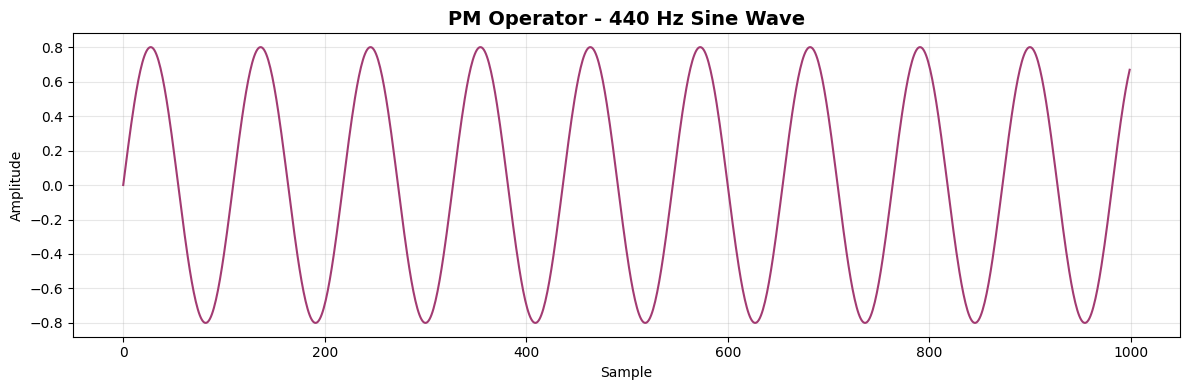

In [2]:
# Cell 3: Test Basic PM Operator
print("=" * 60)
print("TESTING PM OPERATOR")
print("=" * 60)
sample_rate = 48000
operator = caspy.pm.Operator()
operator.set_frequency(440.0, sample_rate)
operator.set_mod_depth(0.8)  # 80% output level
operator.set_mod_index(1.0)  # 1:1 ratio

# Render without envelope
num_samples = int(0.05 * sample_rate)  # 50ms
samples = operator.render(num_samples)

print(f"✓ Generated {len(samples)} samples")
print(f"✓ Frequency: {operator.get_frequency()} Hz")
print(f"✓ Mod Index: {operator.get_mod_index()}")
print(f"✓ Mod Depth: {operator.get_mod_depth()}")
print(f"✓ Sample range: [{min(samples):+.3f}, {max(samples):+.3f}]")

# Visualize waveform
plt.figure(figsize=(12, 4))
plt.plot(samples[:1000], linewidth=1.5, color='#A23B72')
plt.title("PM Operator - 440 Hz Sine Wave", fontsize=14, fontweight='bold')
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

TESTING PM OPERATOR WITH ENVELOPE
✓ Generated 43200 samples with envelope
✓ Note duration: 500ms, Release: 400ms


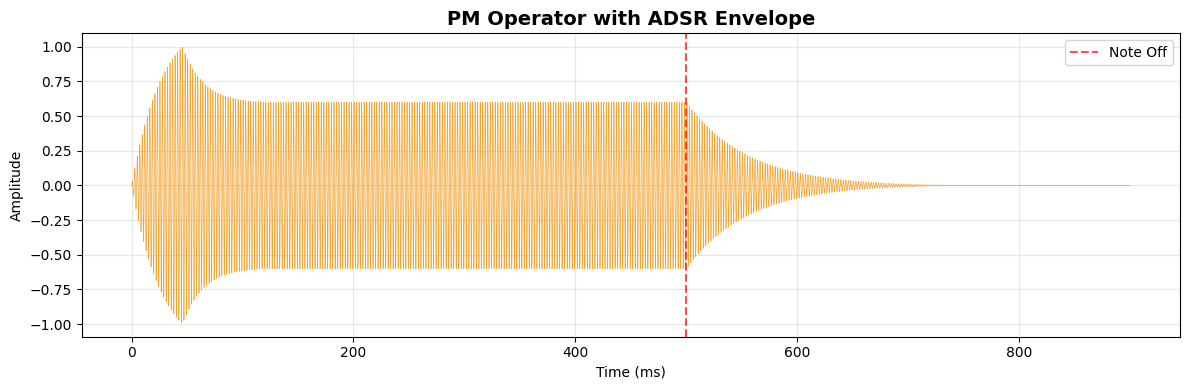

In [3]:
# Cell 4: Test PM Operator with Envelope
print("=" * 60)
print("TESTING PM OPERATOR WITH ENVELOPE")
print("=" * 60)

operator = caspy.pm.Operator()
operator.set_frequency(440.0, sample_rate)
operator.set_mod_depth(1.0)
operator.set_adsr(0.05, 0.1, 0.6, 0.3)  # A=50ms, D=100ms, S=60%, R=300ms
operator.enable_envelope()

# Play a note
operator.note_on()
note_samples = operator.render(int(0.5 * sample_rate))  # 500ms note

operator.note_off()
release_samples = operator.render(int(0.4 * sample_rate))  # 400ms release

all_samples = np.concatenate([note_samples, release_samples])

print(f"✓ Generated {len(all_samples)} samples with envelope")
print(f"✓ Note duration: 500ms, Release: 400ms")

# Visualize
plt.figure(figsize=(12, 4))
time_axis = np.arange(len(all_samples)) / sample_rate * 1000
plt.plot(time_axis, all_samples, linewidth=0.5, color='#F18F01', alpha=0.8)
plt.axvline(x=500, color='red', linestyle='--', label='Note Off', alpha=0.7)
plt.title("PM Operator with ADSR Envelope", fontsize=14, fontweight='bold')
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

TESTING SELF-MODULATION (FEEDBACK)
✓ Feedback 0.0: range [-1.000, +1.000]
✓ Feedback 0.5: range [-1.000, +1.000]
✓ Feedback 1.5: range [-1.000, +1.000]
✓ Feedback 3.0: range [-1.000, +1.000]


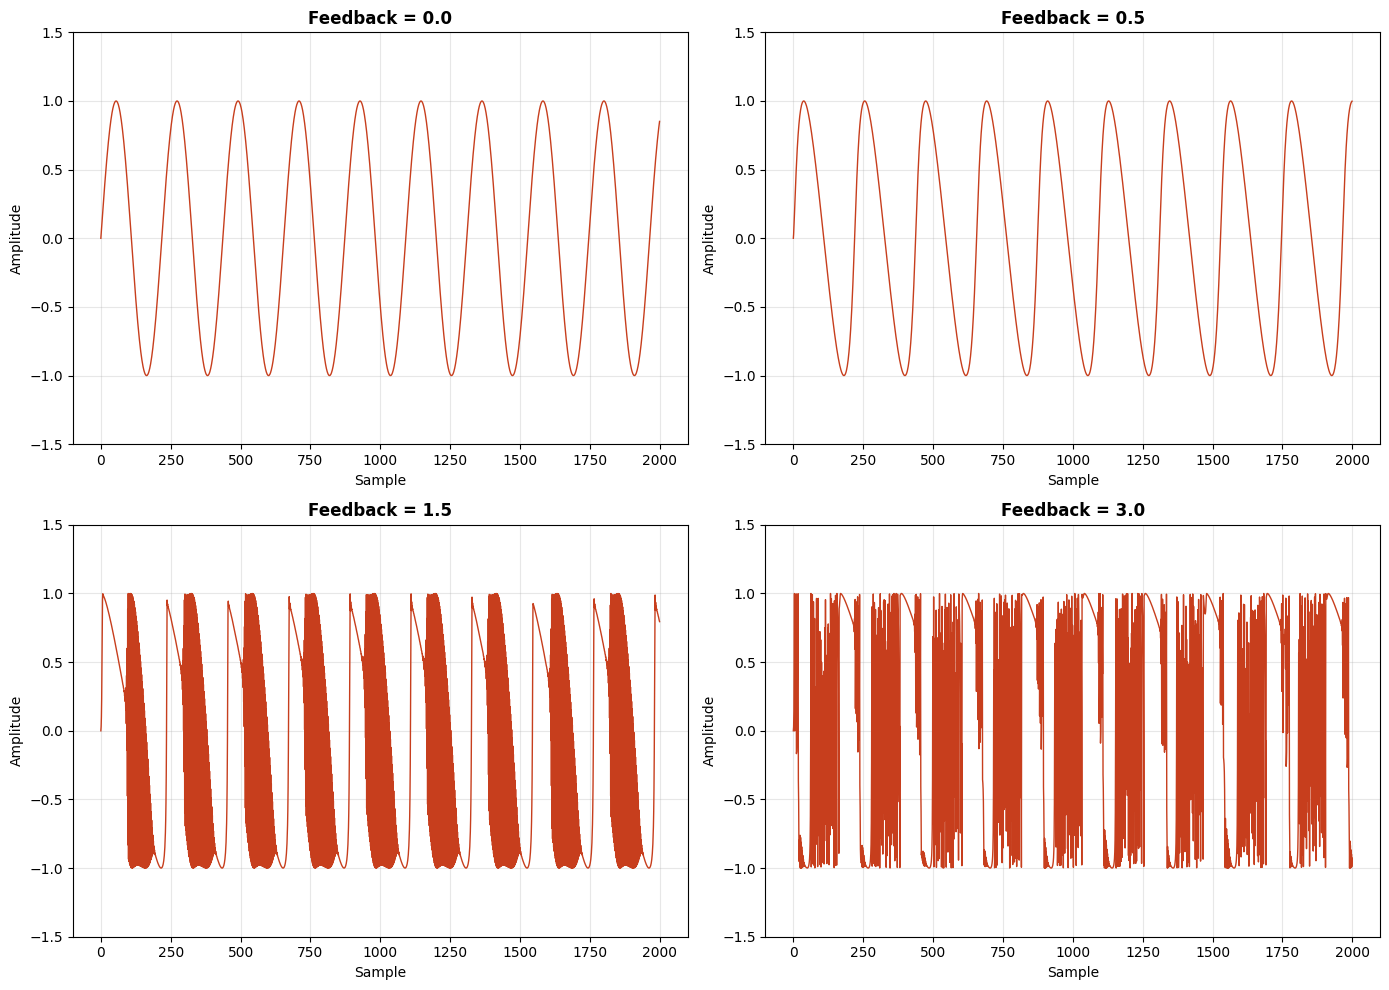

In [4]:
# Cell 5: Test Self-Modulation (Feedback)
print("=" * 60)
print("TESTING SELF-MODULATION (FEEDBACK)")
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
feedback_amounts = [0.0, 0.5, 1.5, 3.0]

for idx, feedback in enumerate(feedback_amounts):
    operator = caspy.pm.Operator()
    operator.set_frequency(220.0, sample_rate)
    operator.set_mod_depth(1.0)
    operator.set_mod_feedback(feedback)
    operator.enable_mod_feedback()
    
    samples = operator.render(2000)
    
    axes[idx].plot(samples, linewidth=1, color='#C73E1D')
    axes[idx].set_title(f"Feedback = {feedback}", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Sample")
    axes[idx].set_ylabel("Amplitude")
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(-1.5, 1.5)
    
    print(f"✓ Feedback {feedback}: range [{min(samples):+.3f}, {max(samples):+.3f}]")

plt.tight_layout()
plt.show()

In [5]:
# Cell 6: Interactive Audio - Single Operator Tone
print("=" * 60)
print("INTERACTIVE AUDIO: SINGLE OPERATOR")
print("=" * 60)

def create_tone(frequency, duration, feedback, attack, decay, sustain, release):
    """Create a tone with specified parameters"""
    operator = caspy.pm.Operator()
    operator.set_frequency(frequency, sample_rate)
    operator.set_mod_depth(1.0)
    operator.set_mod_feedback(feedback)
    
    if feedback > 0:
        operator.enable_mod_feedback()
    
    operator.set_adsr(attack, decay, sustain, release)
    operator.enable_envelope()
    
    # Generate tone
    operator.note_on()
    note_samples = operator.render(int(duration * sample_rate))
    
    operator.note_off()
    release_samples = operator.render(int(release * sample_rate))
    
    audio = np.concatenate([note_samples, release_samples])
    
    # Normalize and apply safety limiting
    audio = np.clip(audio * 0.3, -1.0, 1.0)
    
    return audio

# Create audio examples
print("\nGenerating audio samples...")

# Clean sine wave
clean_sine = create_tone(440.0, 0.5, 0.0, 0.01, 0.05, 0.7, 0.2)
display(Audio(clean_sine, rate=sample_rate))
print("▶ Clean Sine (440 Hz, no feedback)")

# With feedback
feedback_tone = create_tone(440.0, 0.5, 2.0, 0.01, 0.05, 0.7, 0.2)
display(Audio(feedback_tone, rate=sample_rate))
print("▶ With Feedback (440 Hz, feedback=2.0)")

# Bell-like
bell_tone = create_tone(523.25, 0.3, 1.0, 0.001, 0.1, 0.3, 0.5)
display(Audio(bell_tone, rate=sample_rate))
print("▶ Bell-like (C5, quick attack, feedback=1.0)")

# Bass
bass_tone = create_tone(110.0, 0.6, 0.5, 0.005, 0.2, 0.5, 0.3)
display(Audio(bass_tone, rate=sample_rate))
print("▶ Bass (A2, feedback=0.5)")

INTERACTIVE AUDIO: SINGLE OPERATOR

Generating audio samples...


▶ Clean Sine (440 Hz, no feedback)


▶ With Feedback (440 Hz, feedback=2.0)


▶ Bell-like (C5, quick attack, feedback=1.0)


▶ Bass (A2, feedback=0.5)


TESTING FM SYNTHESIS (MODULATOR → CARRIER)
✓ Generated 52800 FM synthesis samples
✓ Modulator: 880 Hz (2x carrier)
✓ Carrier: 440 Hz
✓ Range: [-0.979, +0.994]


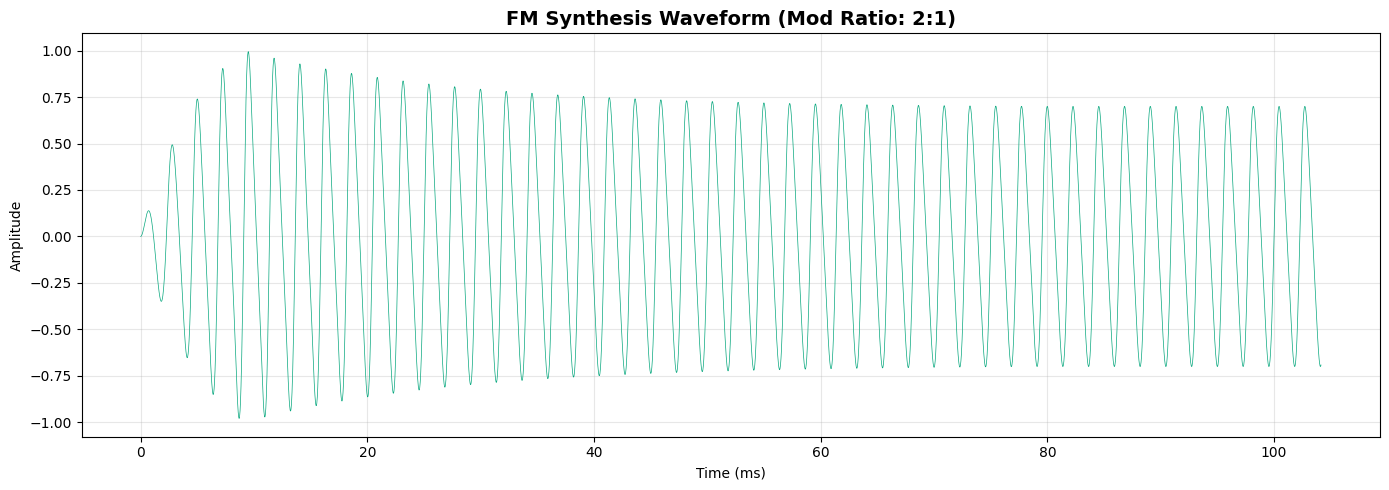

▶ FM Synthesis Audio (440 Hz carrier, 880 Hz modulator)


In [6]:
# Cell 7: Test FM Synthesis (Modulator -> Carrier)
print("=" * 60)
print("TESTING FM SYNTHESIS (MODULATOR → CARRIER)")
print("=" * 60)

# Create modulator
modulator = caspy.pm.Operator()
modulator.set_frequency(440.0, sample_rate)  # Base frequency
modulator.set_mod_index(1.0)  # 2x carrier frequency = 880 Hz
modulator.set_mod_depth(0.5)  # Modulation amount in Hz
modulator.set_adsr(0.01, 0.1, 0.7, 0.2)
modulator.enable_envelope()

# Create carrier
carrier = caspy.pm.Operator()
carrier.set_frequency(440.0, sample_rate)
carrier.set_mod_depth(1.0)
carrier.set_adsr(0.01, 0.1, 0.7, 0.2)
carrier.enable_envelope()

# Render FM synthesis
modulator.note_on()
carrier.note_on()

duration_samples = int(0.8 * sample_rate)
fm_samples = []

for i in range(duration_samples):
    mod_signal = modulator.render()
    carrier_signal = carrier.render(mod_signal)
    fm_samples.append(carrier_signal)

modulator.note_off()
carrier.note_off()

# Add release tail
release_samples = int(0.3 * sample_rate)
for i in range(release_samples):
    mod_signal = modulator.render()
    carrier_signal = carrier.render(mod_signal)
    fm_samples.append(carrier_signal)

fm_audio = np.array(fm_samples)

print(f"✓ Generated {len(fm_audio)} FM synthesis samples")
print(f"✓ Modulator: 880 Hz (2x carrier)")
print(f"✓ Carrier: 440 Hz")
print(f"✓ Range: [{min(fm_audio):+.3f}, {max(fm_audio):+.3f}]")

# Visualize
plt.figure(figsize=(14, 5))
time_axis = np.arange(min(5000, len(fm_audio))) / sample_rate * 1000
plt.plot(time_axis, fm_audio[:5000], linewidth=0.5, color='#06A77D')
plt.title("FM Synthesis Waveform (Mod Ratio: 2:1)", fontsize=14, fontweight='bold')
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Audio playback
fm_audio_safe = np.clip(fm_audio * 0.3, -1.0, 1.0)
display(Audio(fm_audio_safe, rate=sample_rate))
print("▶ FM Synthesis Audio (440 Hz carrier, 880 Hz modulator)")


INTERACTIVE FM EXPLORER

FM Synthesis Presets:


▶ Electric Piano (Ratio 1:1)


▶ Brass-like (Ratio 3:1)


▶ Bell-like (Ratio 7:1)


▶ Metallic (Ratio 5.5:1)
SPECTRUM ANALYSIS


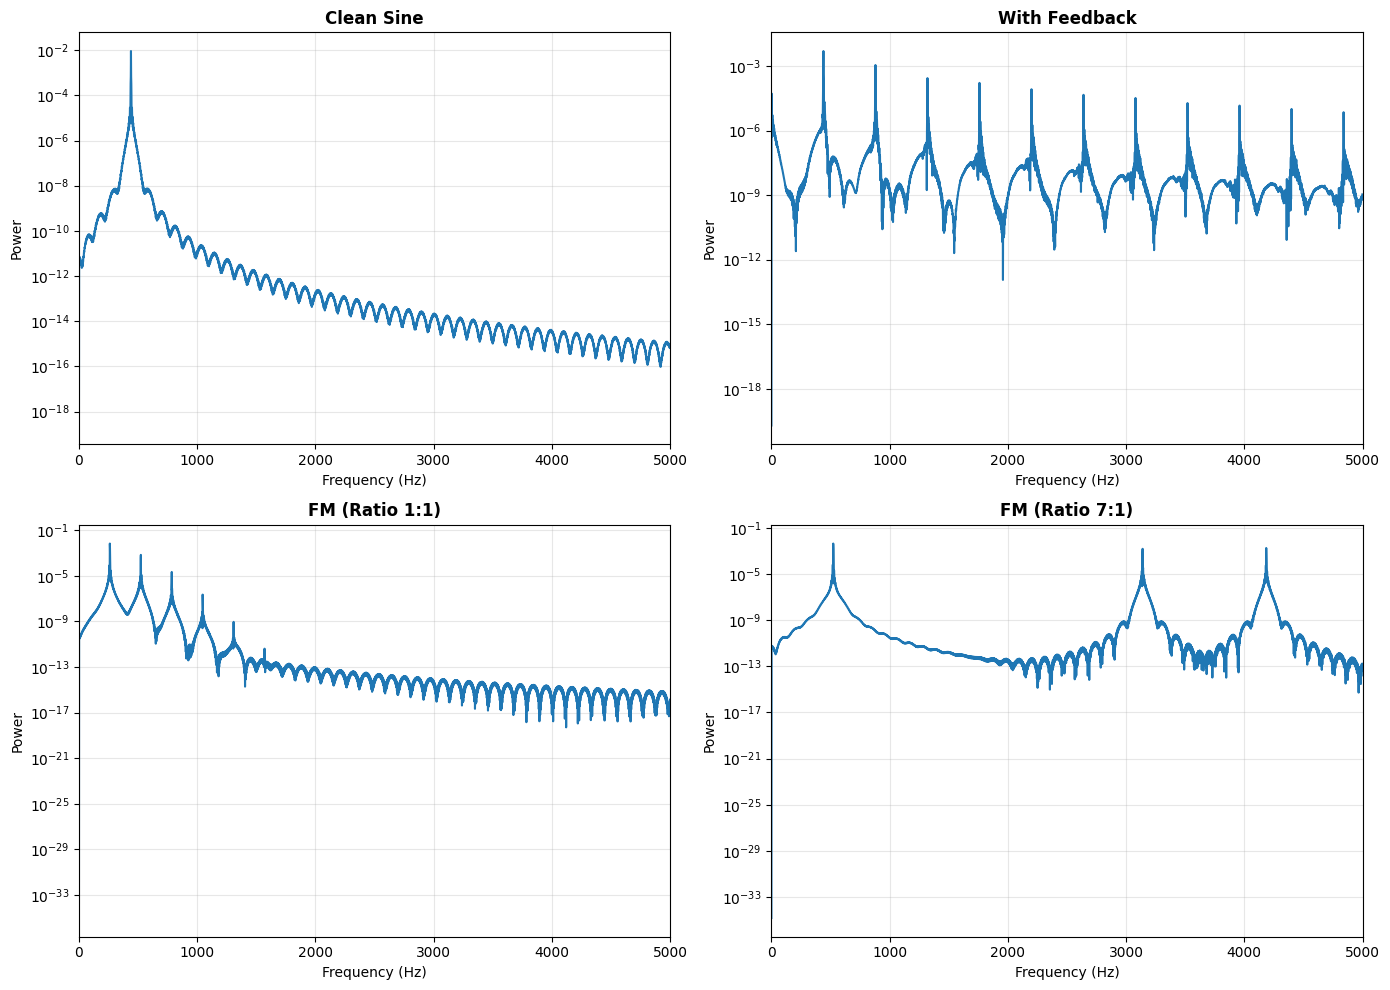

✓ Spectrum analysis complete
  Notice how feedback and FM create harmonic content!


In [7]:
# Cell 8: Interactive FM Synthesis Explorer
print("=" * 60)
print("INTERACTIVE FM EXPLORER")
print("=" * 60)

def generate_fm_sound(carrier_freq, mod_ratio, mod_depth, duration):
    """Generate FM synthesis with adjustable parameters"""
    
    # Modulator
    modulator = caspy.pm.Operator()
    modulator.set_frequency(carrier_freq, sample_rate)
    modulator.set_mod_index(mod_ratio)
    modulator.set_mod_depth(mod_depth)
    modulator.set_adsr(0.01, 0.1, 0.7, 0.2)
    modulator.enable_envelope()
    
    # Carrier
    carrier = caspy.pm.Operator()
    carrier.set_frequency(carrier_freq, sample_rate)
    carrier.set_mod_depth(1.0)
    carrier.set_adsr(0.01, 0.1, 0.7, 0.2)
    carrier.enable_envelope()
    
    # Render
    modulator.note_on()
    carrier.note_on()
    
    samples = []
    for i in range(int(duration * sample_rate)):
        mod_signal = modulator.render()
        carrier_signal = carrier.render(mod_signal)
        samples.append(carrier_signal)
    
    modulator.note_off()
    carrier.note_off()
    
    # Release
    for i in range(int(0.2 * sample_rate)):
        mod_signal = modulator.render()
        carrier_signal = carrier.render(mod_signal)
        samples.append(carrier_signal)
    
    audio = np.array(samples)
    audio = np.clip(audio * 0.3, -1.0, 1.0)
    
    return audio

# Generate presets
print("\nFM Synthesis Presets:")

# Electric Piano
ep_audio = generate_fm_sound(261.63, 1.0, 261.63/300.0, 0.6)  # C4
display(Audio(ep_audio, rate=sample_rate))
print("▶ Electric Piano (Ratio 1:1)")

# Brass
brass_audio = generate_fm_sound(220.0, 3.0, 500.0/220.0, 0.8)  # A3
display(Audio(brass_audio, rate=sample_rate))
print("▶ Brass-like (Ratio 3:1)")

# Bell
bell_audio = generate_fm_sound(523.25, 7.0, 800.0/523.25, 0.5)  # C5
display(Audio(bell_audio, rate=sample_rate))
print("▶ Bell-like (Ratio 7:1)")

# Metallic
metal_audio = generate_fm_sound(440.0, 5.5, 1000.0/440.0, 0.7)  # A4
display(Audio(metal_audio, rate=sample_rate))
print("▶ Metallic (Ratio 5.5:1)")

# Cell 9: Spectrum Analysis
print("=" * 60)
print("SPECTRUM ANALYSIS")
print("=" * 60)

from scipy import signal

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sounds = [
    ("Clean Sine", clean_sine),
    ("With Feedback", feedback_tone),
    ("FM (Ratio 1:1)", ep_audio),
    ("FM (Ratio 7:1)", bell_audio)
]

for idx, (name, audio_data) in enumerate(sounds):
    ax = axes[idx // 2, idx % 2]
    
    # Compute spectrum
    freqs, spectrum = signal.periodogram(audio_data, sample_rate)
    
    # Plot only up to 5 kHz
    mask = freqs < 5000
    ax.semilogy(freqs[mask], spectrum[mask], linewidth=1.5)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power")
    ax.grid(True, alpha=0.3, which='both')
    ax.set_xlim(0, 5000)

plt.tight_layout()
plt.show()

print("✓ Spectrum analysis complete")
print("  Notice how feedback and FM create harmonic content!")

In [8]:
# Cell 10: Summary
print("=" * 60)
print("PM BINDINGS TEST SUMMARY")
print("=" * 60)
print("✓ ADSR Envelope: Working")
print("✓ PM Operator: Working")
print("✓ Envelope Integration: Working")
print("✓ Self-Modulation (Feedback): Working")
print("✓ FM Synthesis (Modulation): Working")
print("✓ Audio Rendering: Working")
print("=" * 60)
print("All PM module bindings tested successfully!")

PM BINDINGS TEST SUMMARY
✓ ADSR Envelope: Working
✓ PM Operator: Working
✓ Envelope Integration: Working
✓ Self-Modulation (Feedback): Working
✓ FM Synthesis (Modulation): Working
✓ Audio Rendering: Working
All PM module bindings tested successfully!
